In [1]:
import sys 

sys.path.append("..")

In [2]:
import torch
import torch.nn as nn
from model import FM_PhysMamba_UNET, ODESolver
from torchvision.transforms import v2
from utils import predict_large_image_vectorized
from data.utils import restandardize_tensor
from PIL import Image
import matplotlib.pyplot as plt

### Dense-Haze Weight

In [4]:
checkpoint_path = "../checkpoints/(TRAIN)DENSEHAZE_FM_PhysicMamba_UNET_Version2_Small_V21/stage_0_finished.pt"
device = "cuda"

checkpoint = torch.load(checkpoint_path,
                        map_location = device,
                        weights_only = False)
state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()} # Clean DDP keys


dense_model = FM_PhysMamba_UNET("../configs/model_cfgs/small.yaml").to(device)
dense_model.load_state_dict(state_dict, strict=True)
dense_model.eval()
dense_solver = ODESolver(dense_model)

In [5]:
def preprocess_single_image(image, device="cuda"):
    """
    Preprocesses a single raw image (PIL Image or Numpy array) for inference.
    
    Steps:
    1. Converts to Tensor (v2.ToImage)
    2. Scales to [0, 1] float32 (v2.ToDtype)
    3. Normalizes using mean=0.5, std=0.5 (Matches training)
    4. Adds Batch Dimension (1, C, H, W)
    5. Moves to Device
    """
    # Exact same logic as 'eval_common' in get_haze_transforms
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

    # Apply transform: (C, H, W)
    img_tensor = transform(image)

    # Add batch dimension: (1, C, H, W)
    img_tensor = img_tensor.unsqueeze(0)

    return img_tensor.to(device)

In [6]:
def plot_inference_results(hazy_tensor, restored_tensor, save_path=None):
    """
    Plots the Hazy Input vs. Restored Output side-by-side using Matplotlib.
    
    Args:
        hazy_tensor (torch.Tensor): The preprocessed input tensor (1, C, H, W).
                                    Expected to be normalized (mean=0.5, std=0.5).
        restored_tensor (torch.Tensor): The model output tensor (1, C, H, W).
                                        Expected to be normalized (mean=0.5, std=0.5).
        save_path (str, optional): If provided, saves the plot to this file path.
    """
    # 1. Un-normalize and move to CPU
    # We use .detach() to ensure we don't carry gradients, and squeeze(0) to drop batch dim
    hazy_disp = restandardize_tensor(hazy_tensor.detach().squeeze(0).cpu())
    restored_disp = restandardize_tensor(restored_tensor.detach().squeeze(0).cpu())

    # 2. Convert to Numpy Format for Matplotlib: (C, H, W) -> (H, W, C)
    hazy_np = hazy_disp.permute(1, 2, 0).numpy()
    restored_np = restored_disp.permute(1, 2, 0).numpy()

    # 3. Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Left: Hazy Input
    axes[0].imshow(hazy_np)
    axes[0].set_title("Input (Hazy)", fontsize=14, fontweight='bold')
    axes[0].axis("off")  # Remove axis ticks

    # Right: Restored Output
    axes[1].imshow(restored_np)
    axes[1].set_title("Output (Restored)", fontsize=14, fontweight='bold')
    axes[1].axis("off")

    plt.tight_layout()

    # 4. Save and Show
    if save_path:
        print(f"Saving comparison plot to: {save_path}")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [7]:
def infer_image(image_path, solver, save_path = "results/result_comparison.png"):
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = preprocess_single_image(raw_img, device="cuda")
    
    restored_tensor = predict_large_image_vectorized(
        solver=solver, 
        full_img_tensor=input_tensor, 
        device="cuda",
        tile_size=256,
        overlap_ratio=0.25
    )
    
    plot_inference_results(
        hazy_tensor=input_tensor, 
        restored_tensor=restored_tensor,
        save_path=save_path
    )

In [9]:
import os 
os.getcwd()

'/workspace/dehazing/experiments'

Saving comparison plot to: imgs/results/traffic_1.png


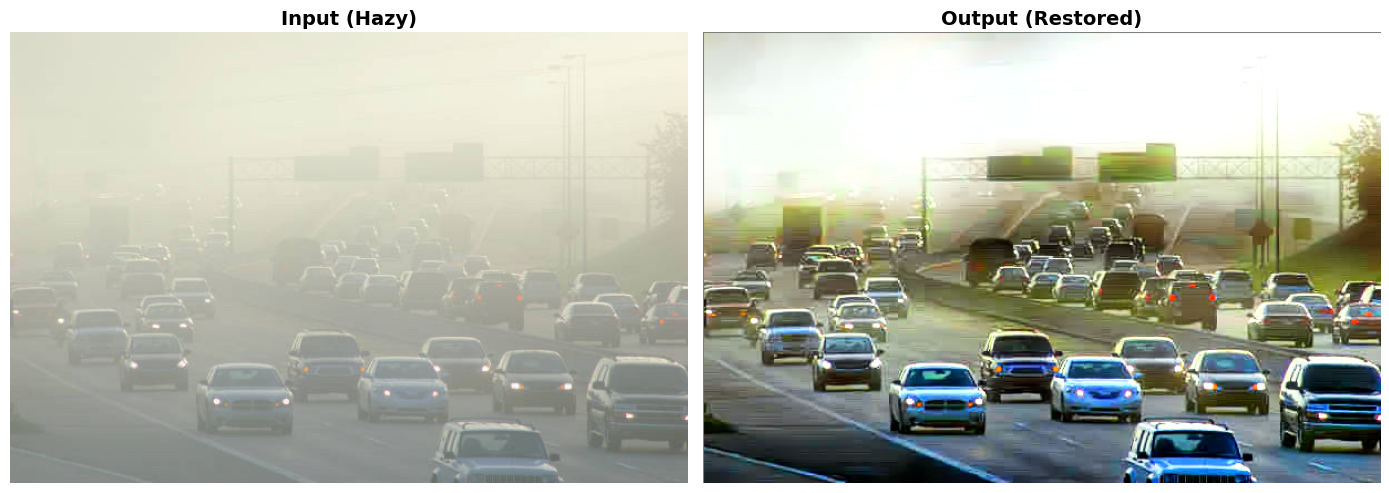

In [10]:
image_path = "imgs/test_images.jpeg"
infer_image(image_path, dense_solver, save_path = "imgs/results/traffic_1.png")

Saving comparison plot to: imgs/results/traffic_2.png


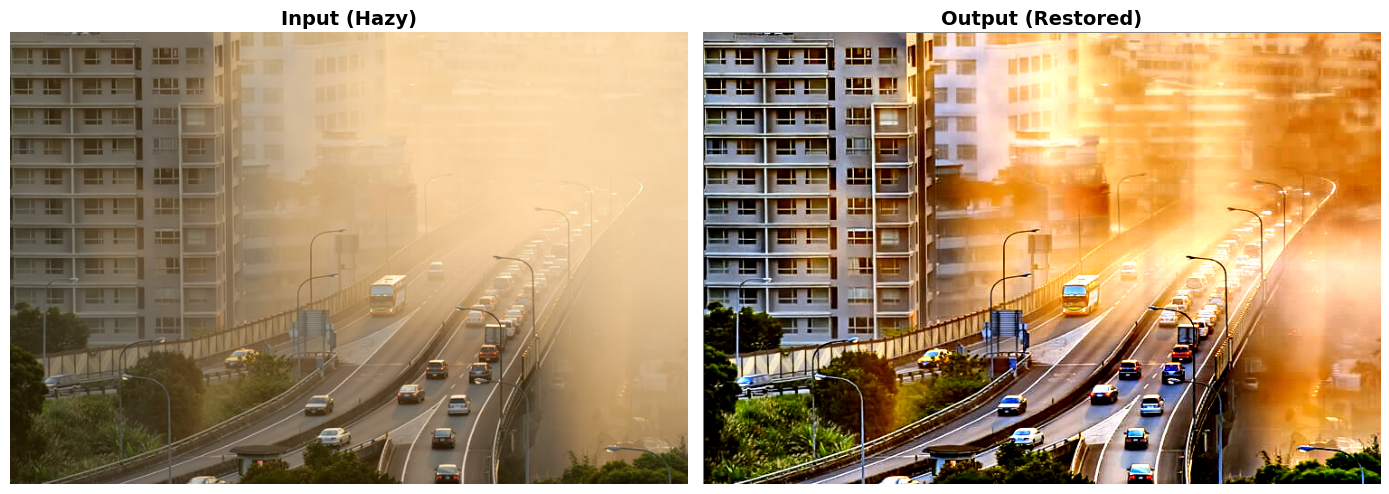

In [11]:
image_path = "imgs/test_images3.jpg"
infer_image(image_path, dense_solver, save_path = "imgs/results/traffic_2.png")

Saving comparison plot to: imgs/results/traffic_3.png


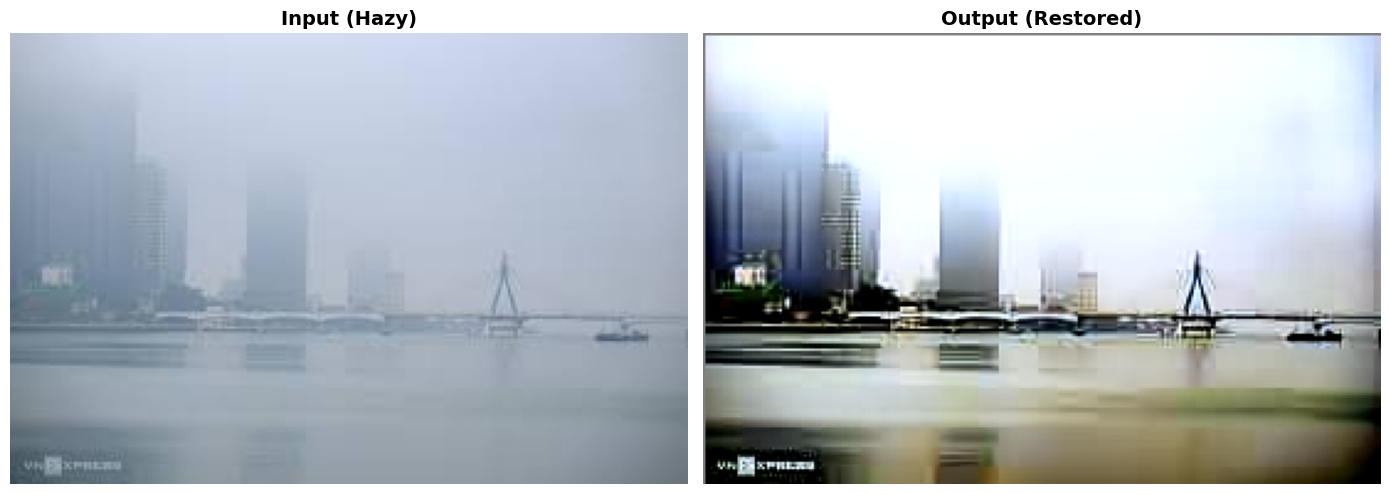

In [12]:
image_path = "imgs/test_images5.jpeg"
infer_image(image_path, dense_solver, save_path = "imgs/results/traffic_3.png")

## NH-Haze

In [38]:
checkpoint_path = "../checkpoints/NHHAZE_FM_PhysicMamba_UNET_Version2_Small_V21/stage_0_finished.pt"
device = "cuda"

checkpoint = torch.load(checkpoint_path,
                        map_location = device,
                        weights_only = False)
state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()} # Clean DDP keys


nh_model = FM_PhysMamba_UNET("../configs/model_cfgs/small.yaml").to(device)
nh_model.load_state_dict(state_dict, strict=True)
nh_model.eval()
nh_solver = ODESolver(reside_model)



Saving comparison plot to: imgs/result_comparison.png


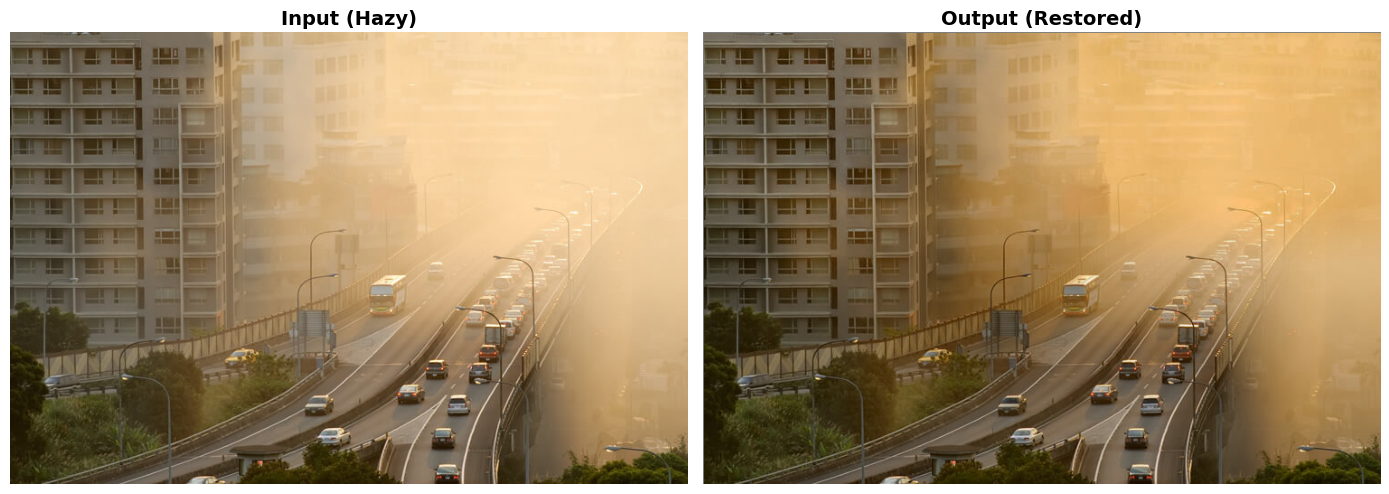

In [40]:
image_path = "imgs/test_images3.jpg"
infer_image(image_path, nh_solver)

Saving comparison plot to: imgs/result_comparison.png


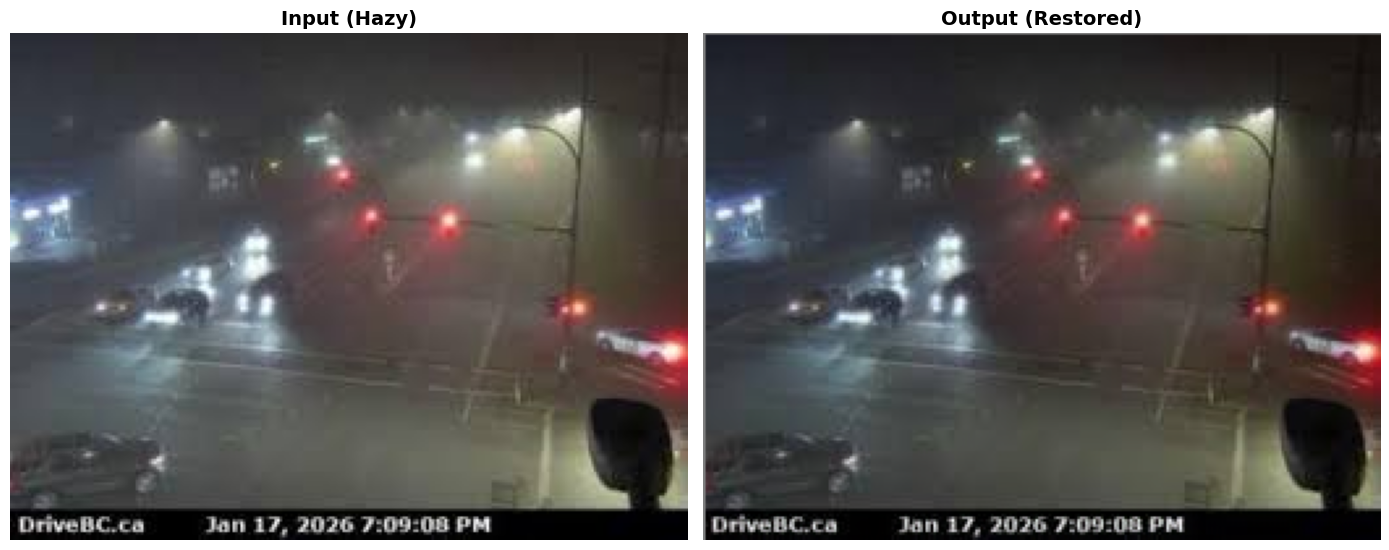

In [42]:
image_path = "imgs/test_images4.jpeg"
infer_image(image_path, nh_solver)

Saving comparison plot to: imgs/result_comparison.png


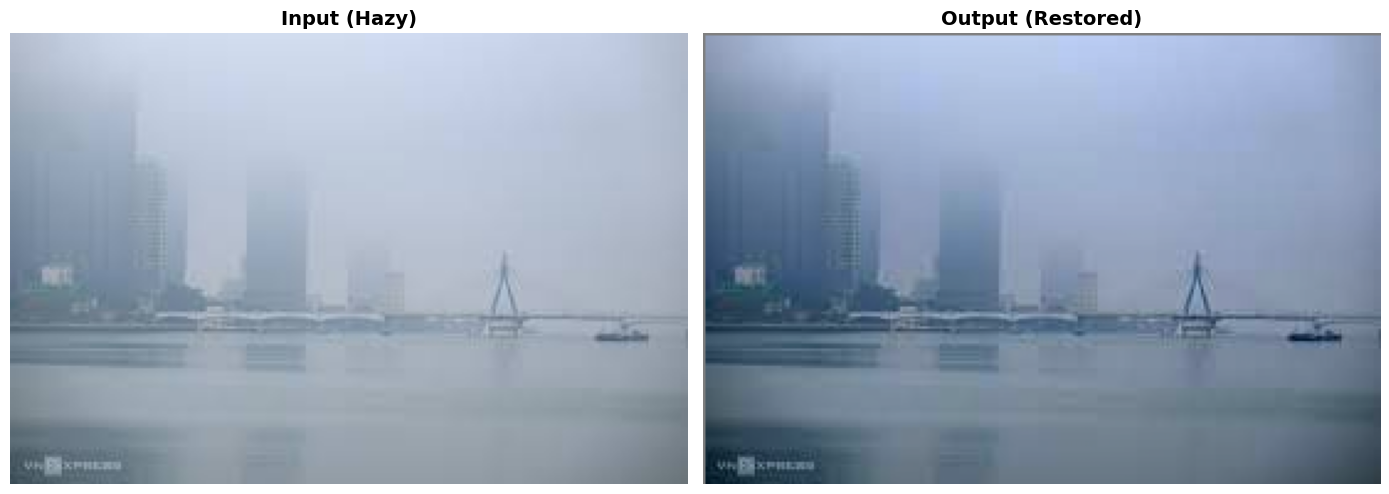

In [46]:
image_path = "imgs/test_images5.jpeg"
infer_image(image_path, nh_solver)

## Reside Indoors

Saving comparison plot to: imgs/result_comparison.png


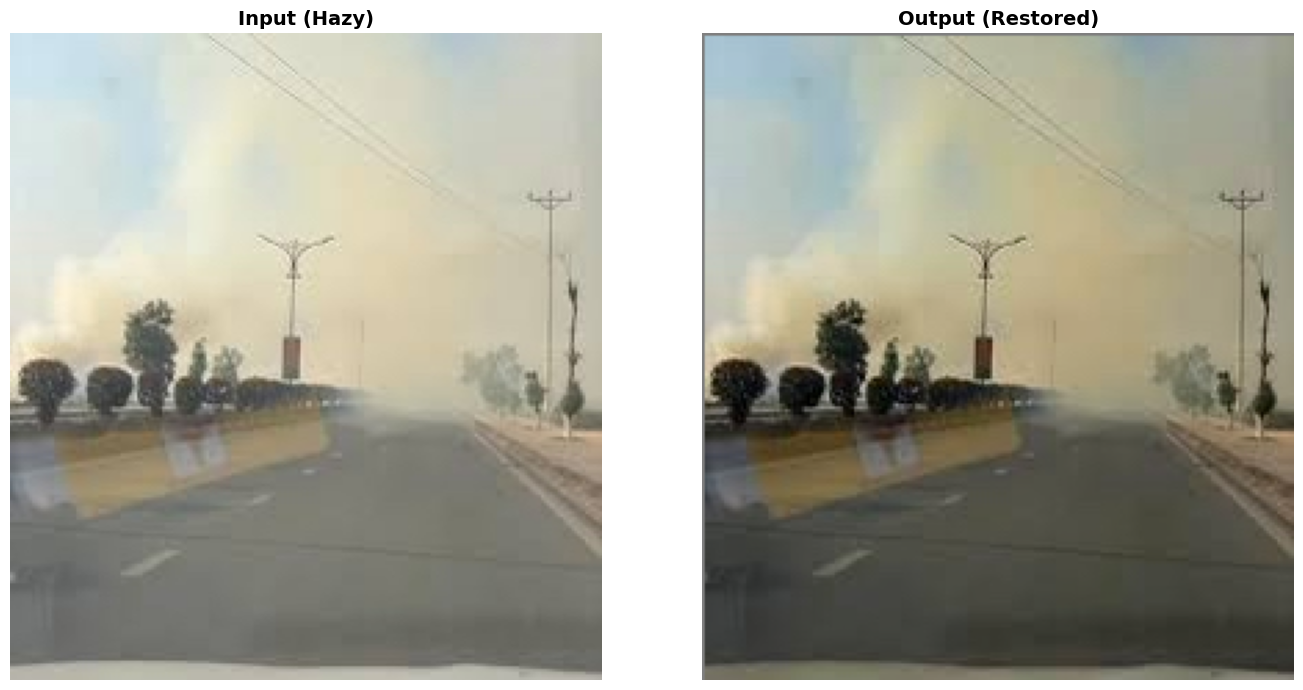

In [34]:
checkpoint_path = "../checkpoints/RESIDE-INDOOR_FM_PhysicMamba_UNET_Version2_Small_V21/stage_0_finished.pt"
device = "cuda"

checkpoint = torch.load(checkpoint_path,
                        map_location = device,
                        weights_only = False)
state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()} # Clean DDP keys


reside_model = FM_PhysMamba_UNET("../configs/model_cfgs/small.yaml").to(device)
reside_model.load_state_dict(state_dict, strict=True)
reside_model.eval()
reside_solver = ODESolver(reside_model)

image_path_2 = "imgs/test_images2.jpeg"
infer_image(image_path_2, reside_solver)

Saving comparison plot to: imgs/result_comparison.png


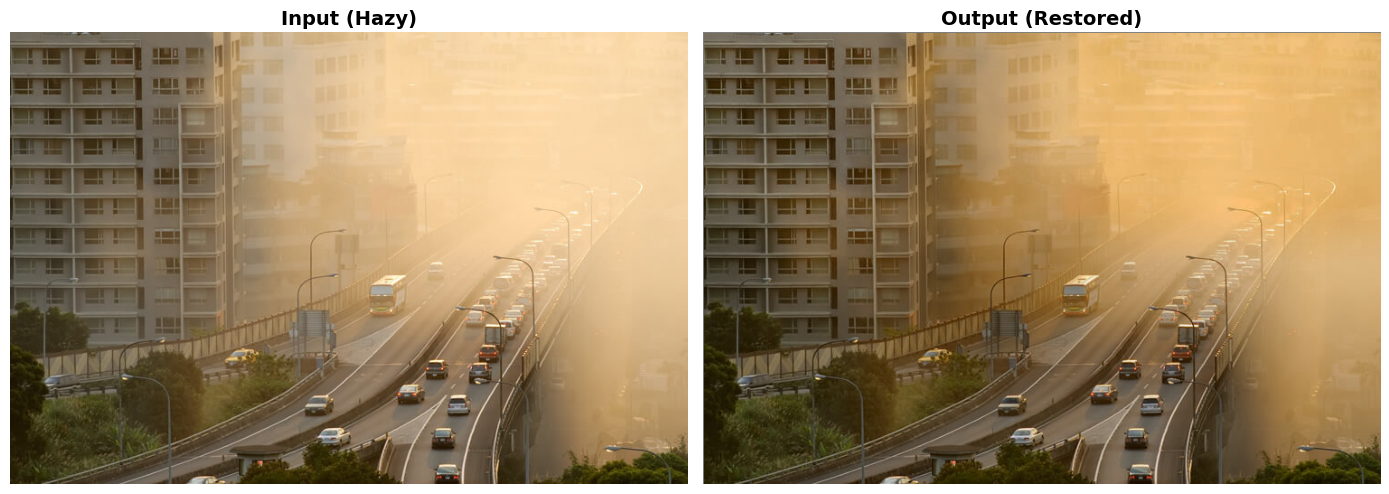

In [37]:
image_path = "imgs/test_images3.jpg"
infer_image(image_path, reside_solver)

Saving comparison plot to: imgs/result_comparison.png


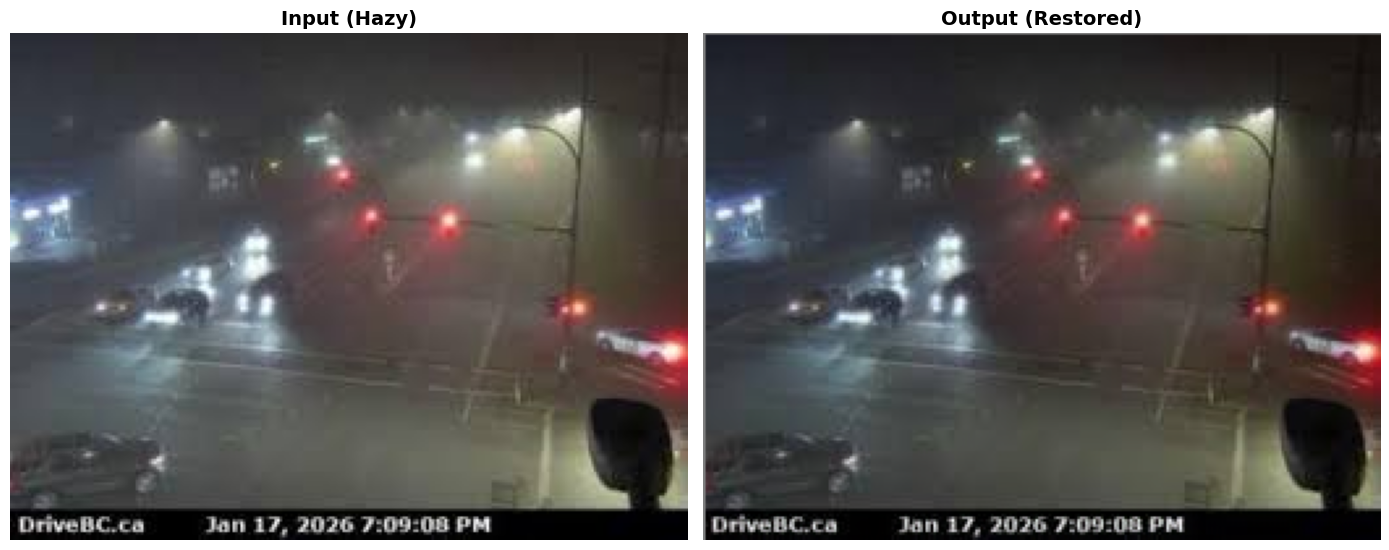

In [44]:
image_path = "imgs/test_images4.jpeg"
infer_image(image_path, reside_solver)